In [1]:
quiet_library <- function(...){suppressPackageStartupMessages(library(...))}
quiet_library(dplyr)
quiet_library(purrr)
quiet_library(tidyr)
quiet_library(data.table)
quiet_library(Seurat)
quiet_library(SeuratDisk)
quiet_library(ggplot2)
quiet_library(glue)
quiet_library(hise)
quiet_library(H5weaver)
quiet_library(gridExtra)

options(repr.matrix.max.cols=150, repr.matrix.max.rows=200, mc.cores = 20, future.globals.maxSize = 2000 * 1024^2)
fig.size <- function (height, width) {
    options(repr.plot.height = height, repr.plot.width = width)
}

In [2]:
wd <- "/home/workspace/IFN"
fig_dir <- file.path(wd, "Figures")

In [6]:
stims <- c("IFNa", "IFNg")
celltypes <- c("Bcell", "Tcell", "NK", "Monocyte")
subtypes <- c("CD4 Naive", "CD4 Memory", "Treg", "CD8 Naive", "CD8 Memory", "MAIT", "gdT", 
              "B Naive", "B Memory", "Plasma", 
              "NK.CD56hi", "NK.CD56dim", 
              "CD14 Monocyte")
celltype_cols <- c("#00b4d8", "#1b4332", "#ffbf69", "#78290f" )
subtype_cols <- c("#03045e", "#023e8a", "#0077b6", "#0096c7", "#00b4d8", "#48cae4", "#90e0ef",
                   "#1b4332", "#52b788", "#b7e4c7",
                    "#ff9f1c", "#ffbf69", 
                   "#78290f"
                  )
stim_cols <- c("#e9c46a", "#f4a261", "#e76f51", "#264653", "#2a9d8f")

In [7]:
# cohorts metadata
meta <- fread(file.path(wd, "Cohort_IFN_scores", "IFN_Cohort_Comparison_Sample_Sheet.csv")) %>% filter(Group != "Control")

cohorts <- c("ALPS", "SLE_Science", "Acute_Covid", "Long_Covid", "Flu", "Malaria", 
             "RA_external", "BRI_aging_M", "BRI_aging_F", "MM_BMMC",
            "MM_Pretreatment", "MM_EndInduction", "MM_BMMC", "RA", "SLE")

In [8]:
# read in scores across cohorts
scores_df <- map_dfr(cohorts, function(cohort){
    
    map_dfr(celltypes, function(c){
        res <- fread(file.path(wd, "Cohort_IFN_scores", "NMF", cohort, glue("{cohort}_{c}_NMF_scores_scaled_v2.csv"))) %>% 
                    as.data.frame() 
        
        colnames(res) <- colnames(res) %>% stringr::str_extract("(?<=_).*") %>% replace_na(0) 
        rownames(res) <- stims
        res <- t(res) %>% as.data.frame()
        res$Cohort <- cohort
        res$celltype <- c
        res$KitID <- rownames(res)
        
        res
    
    })
})
scores_df <- scores_df %>% left_join(meta %>% select(KitID, SubjectID, Cohort, Misc), by = c("KitID", "Cohort"))

In [9]:
# set non-responding IFNg cell type NK scores to zero 
scores_df$IFNg[scores_df$celltype == "NK"] <- 0

### 4B. Average IFN Scores by Immune Group Bubbleplot

In [56]:
cohorts_select <- c("SLE_Science", "MM_BMMC", "Flu", "Acute_Covid", "Long_Covid", "Malaria", 
                    "RA_external", "BRI_aging_F", "BRI_aging_M", "ALPS")
scores_df_select <- scores_df %>% 
    filter(Cohort %in% cohorts_select)

In [41]:
# assign cohorts to general immune categories 
scores_df_select$group <- recode(scores_df_select$Cohort,
                        "SLE_Science" = "Autoimmunity",
                          "MM_BMMC" = "Myeloma", 
                        "Flu" = "Infection",  
                        "Acute_Covid" = "Infection", 
                        "Long_Covid" = "Infection",
                        "Malaria" = "Infection", 
                        "RA_external" = "Autoimmunity", 
                        "BRI_aging_F" = "Aging",
                        "BRI_aging_M" = "Aging",
                        "ALPS" = "ALPS")


In [44]:
# get average scores and variation per cohort and cell type
avg_positions <- scores_df_select %>%
  group_by(group, celltype) %>%
  summarise(
    avg_IFNa = mean(IFNa),
    avg_IFNg = mean(IFNg),
    var_IFNa = var(IFNa),
    var_IFNg = var(IFNg)
  )
avg_positions$var_combined <- (avg_positions$var_IFNa + avg_positions$var_IFNg) / 2

`summarise()` has grouped output by 'group'. You can override using the
`.groups` argument.


null device 
          1

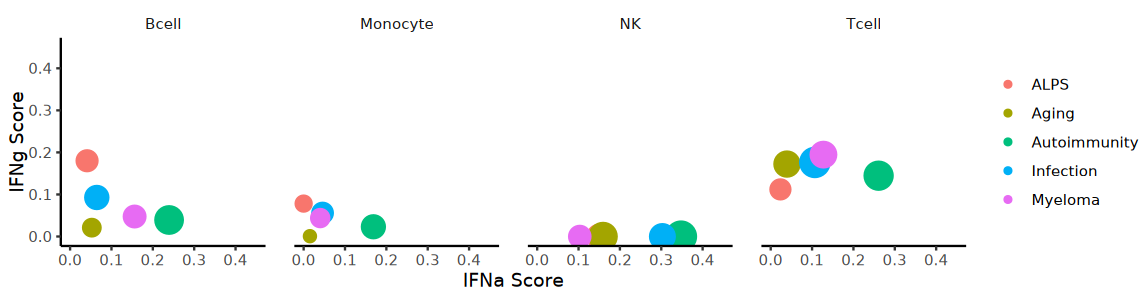

In [45]:
fig.size(2.5,9.5)
#pdf(file.path(fig_dir, "Fig4", "IFN_Score_Average_Immune_Group_Scatterplots.pdf"), height = 2.5, width = 9.8)
ggplot(avg_positions, aes(x=avg_IFNa, y=avg_IFNg, color = group, size = var_combined)) +
    xlim(0,0.45) + ylim(0,0.45) + 
    geom_point() + 
    facet_wrap(~celltype, ncol = 4) + 
    theme_classic() +  
    scale_size(range = c(3,8), guide = "none") + 
    theme(strip.background = element_blank(), panel.spacing = unit(1.2, "lines"),
         legend.title = element_blank()
      ) + 
    labs(x = "IFNa Score", y = "IFNg Score")

dev.off()

### 4C. Cohort Scores Boxplot

In [53]:
group_level <- c("M", "F", "Managed", "Flare", "ACPA_neg", "ACPA_pos", "Mild", "Severe", "Long", "Flu", "Malaria", 
                  "MM", "MGUS", "SMMh", "SMMl", "ALPS")
scores_df$Misc <- factor(scores_df$Misc, levels = group_level)

In [57]:
# format scores 
scores_df_long <- scores_df_select %>% 
    pivot_longer(!c(celltype, Cohort, KitID, SubjectID, Misc), names_to = "stim", values_to = "score")

Warning message:
“Removed 104 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 130 rows containing missing values or values outside the scale range
(`geom_point()`).”


null device 
          1

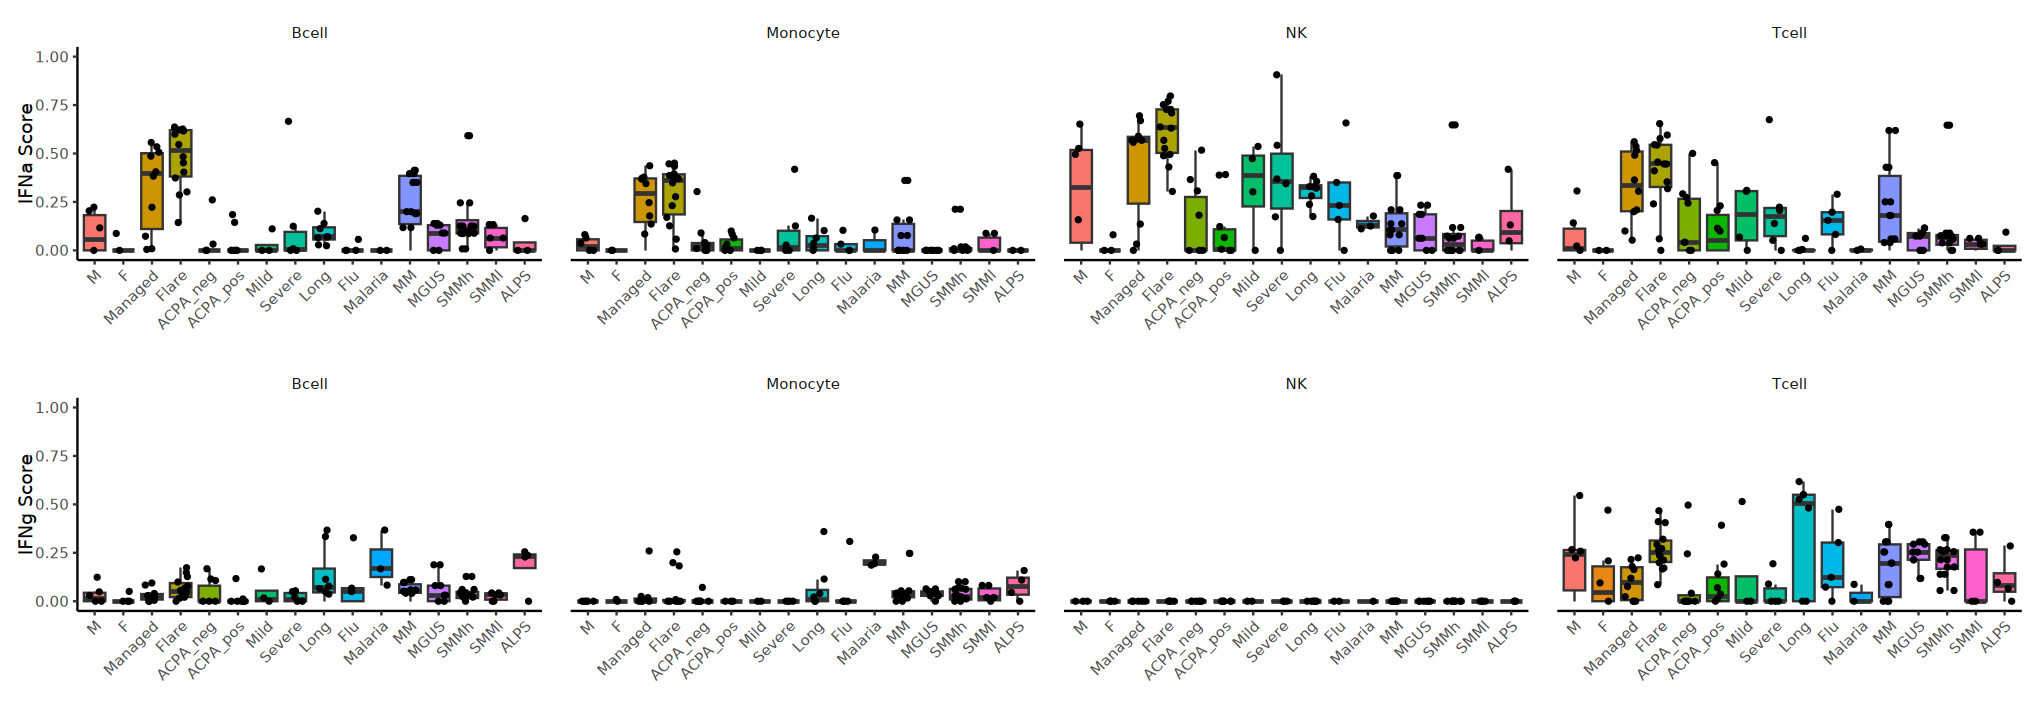

In [58]:
fig.size(6,17)
#pdf(file.path(fig_dir, "Fig4", "IFN_Score_Cohort_Boxplots.pdf"), height = 6, width = 17)
gg1 <- ggplot(scores_df_long %>% filter(stim == "IFNa"), aes(x=Misc, y=score, fill=Misc)) +
    geom_boxplot(outlier.shape = NA) + 
    geom_jitter(width = 0.25, size = 1) + 
    ylim(0,1) + 
    facet_wrap(~celltype, ncol = 4) + 
    theme_classic() + 
    xlab("") + ylab("IFNa Score") + theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1)) + 
    theme(legend.position = "none", strip.background = element_blank()) + 
    theme(strip.background = element_blank(),
          panel.spacing = unit(1.2, "lines")
      )

gg2 <- ggplot(scores_df_long %>% filter(stim == "IFNg"), aes(x=Misc, y=score, fill=Misc)) +
    geom_boxplot(outlier.shape = NA) + 
    geom_jitter(width = 0.25, size = 1)  + 
    ylim(0,1) +
    facet_wrap(~celltype, ncol = 4) + 
    theme_classic() + 
    xlab("") + ylab("IFNg Score") + theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1)) + 
    theme(legend.position = "none", strip.background = element_blank()) + 
    theme(strip.background = element_blank(),
          panel.spacing = unit(1.2, "lines")
      )
gg1/gg2
dev.off()

### 4D. IFN Score MSD Correlations

In [ ]:
# internal cohorts with MSD
cohorts_internal <- c("ALPS", "RA", "SLE", "MM_Pretreatment")

In [94]:
# read-in MSD results
msd <- fread(file.path(wd, "Cohort_IFN_scores", "MSD_results_Emma.csv"), header = T)

In [95]:
# normalize MSD inteferon measurements to cohort controls
msd_mod <- map_dfr(cohorts_internal, function(x){
    
    msd %>% filter(Cohort == x) %>%
      mutate(mean_IFNa_b = mean(IFNa_b[Status == "Control"])) %>%
      mutate(IFNa_log2FC = log2(IFNa_b / mean_IFNa_b)) %>%
      mutate(mean_IFNg = mean(IFNg[Status == "Control"])) %>%
      mutate(IFNg_log2FC = log2(IFNg / mean_IFNg)) %>%
        select(-c(IFNa, IFNb, IFNg)) 
    
    }) %>% filter(Status != "Control")
msd_mod[msd_mod == -Inf] <- 0

In [106]:
# join MSD and scores dataframes
msd_final <- msd_mod %>% left_join(scores_df %>% filter(Cohort %in% cohorts_internal) %>% 
                                   select(KitID, IFNa, IFNg, Misc, Cohort, celltype),
                                   by = c("KitID", "Cohort")) 
msd_final$celltype <- factor(msd_final$celltype, levels = celltypes)

#### IFNa

`geom_smooth()` using formula = 'y ~ x'


null device 
          1

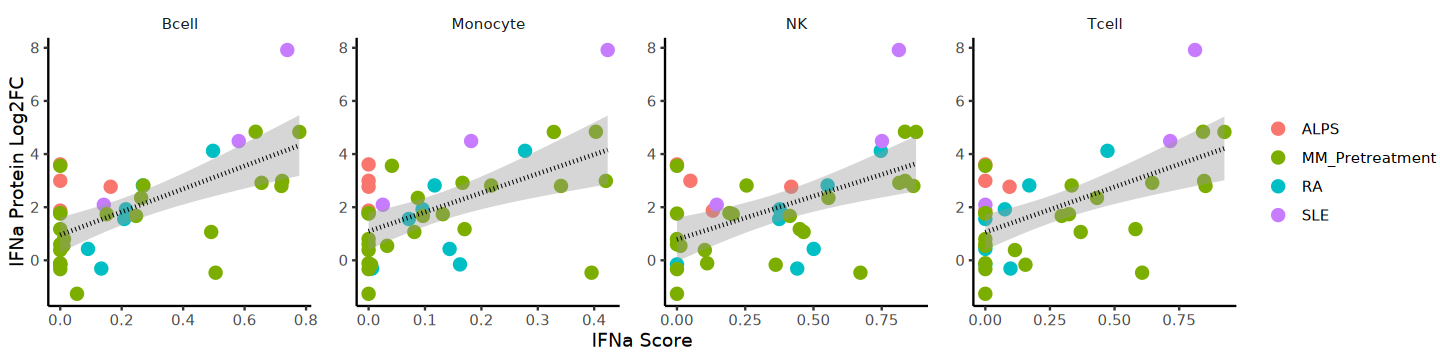

In [107]:
fig.size(3,12)
#pdf(file.path(fig_dir, "Fig4", "IFNa_Score_Protein_Correlation_Scatterplots_L1.pdf"), height = 3, width = 12)
ggplot(msd_final, aes(x = IFNa, y = IFNa_log2FC, color = Cohort)) +
  geom_point(size = 3) + 
  facet_wrap(~celltype, ncol = 4, scales = "free") + 
  theme_classic() +
  labs(x = "IFNa Score", y = "IFNa Protein Log2FC") + 
  geom_smooth(method = "lm", color = "black", linetype = "dotted", fullrange = T) + 
  theme(strip.background = element_blank(), panel.spacing = unit(1.2, "lines"),
         slegend.title = element_blank())
dev.off()

In [109]:
# run spearman correlations per cell type
correlations <- msd_final %>%
  group_by(celltype) %>%
  summarize(correlation = cor.test(IFNa, IFNa_log2FC, method = "spearman")$estimate,
           pval = cor.test(IFNa, IFNa_log2FC, method = "spearman")$p.val)

Warning message:
“There were 8 warnings in `summarize()`.
The first warning was:
ℹ In argument: `correlation = cor.test(IFNa, IFNa_log2FC, method =
  "spearman")$estimate`.
ℹ In group 1: `celltype = "Bcell"`.
Caused by warning in `cor.test.default()`:
! Cannot compute exact p-value with ties
ℹ Run `dplyr::last_dplyr_warnings()` to see the 7 remaining warnings.”


In [ ]:
correlations %>% fwrite(file.path(wd, "Tables", "Stats", "Fig4D_IFNa_MSD_Correlation_Spearman.csv"))

#### IFNg

`geom_smooth()` using formula = 'y ~ x'


null device 
          1

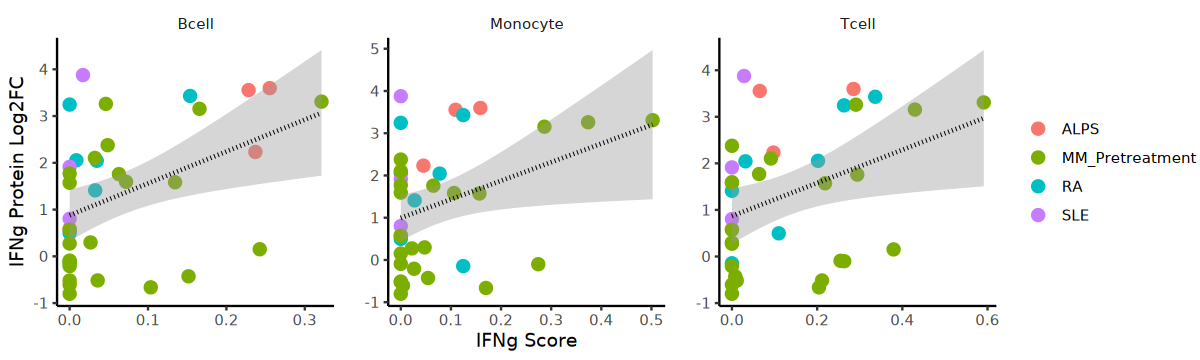

In [114]:
fig.size(3,10)
#pdf(file.path(fig_dir, "Fig4", "IFNg_Score_Protein_Correlation_Scatterplots_L1.pdf"), height = 3, width = 12)
ggplot(msd_final %>% filter(celltype != "NK"), aes(x = IFNg, y = IFNg_log2FC, color = Cohort)) +
  geom_point(size = 3) + 
  facet_wrap(~celltype, ncol = 3, scales = "free") + 
  theme_classic() +
  labs(x = "IFNg Score", y = "IFNg Protein Log2FC") + 
  geom_smooth(method = "lm", color = "black", linetype = "dotted", fullrange = T) + 
  theme(strip.background = element_blank(), panel.spacing = unit(1.2, "lines"),
         legend.title = element_blank())
dev.off()

In [340]:
# run spearman correlations per cell type
correlations <- msd_final %>%
  group_by(celltype) %>%
  summarize(correlation = cor.test(IFNg, IFNg_log2FC, method = "spearman")$estimate,
           pval = cor.test(IFNg, IFNg_log2FC, method = "spearman")$p.val)

Warning message:
“There were 8 warnings in `summarize()`.
The first warning was:
ℹ In argument: `correlation = cor.test(IFNg, IFNg_log2FC, method =
  "spearman")$estimate`.
ℹ In group 1: `celltype = Bcell`.
Caused by warning in `cor.test.default()`:
! Cannot compute exact p-value with ties
ℹ Run `dplyr::last_dplyr_warnings()` to see the 7 remaining warnings.”


In [342]:
correlations %>% fwrite(file.path(wd, "Tables", "Stats", "Fig4D_IFNg_MSD_Correlation_Spearman.csv"))